In [ ]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cfe.data import FateAnnData
from cfe.metric.metric_correlation import calculate_correlation
from cfe.metric.metric_position_predict import calculate_position_predict
from cfe.metric.metric_featureimp import (
    calculate_overall_feature_importance,
    calculate_featureimp_cor,
    calculate_featureimp_enrichment,
    fi_ranger_rf_tiny,
    fi_ranger_rf_lite
)
from cfe.metric.cluster_metric_v2 import calculate_mapping_branches, calculate_mapping_milestones,calculate_mapping
from cfe.metric._topology_metric.metric_him import calculate_him
from cfe.metric.topology_metric import calc_isomorphic, calculate_edge_flip
import matplotlib.pyplot as plt
import seaborn as sns

[2025年10月09日 16时22分45秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

In [2]:
fadata = cfe.data.read_erythroid_lineage()
fadata

[2025年10月09日 16时22分46秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                
                        DEBUG    FateAnnData add_trajectory                                                        


AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

In [3]:
# fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
# fadata.obs.index

[2025年10月09日 16时22分49秒] DEBUG    plot_trajectory                                                             
[2025年10月09日 16时26分53秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年10月09日 16时27分19秒] DEBUG    add waypoints shape is (205, 9815), finished!                               
[2025年10月09日 16时27分25秒] DEBUG    plot_trajectory                                                             
[2025年10月09日 16时31分32秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年10月09日 16时32分01秒] DEBUG    add waypoints shape is (205, 9815), finished!                               


AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'milestone'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'cfe', 'milestone_color_dict', 'milestone_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

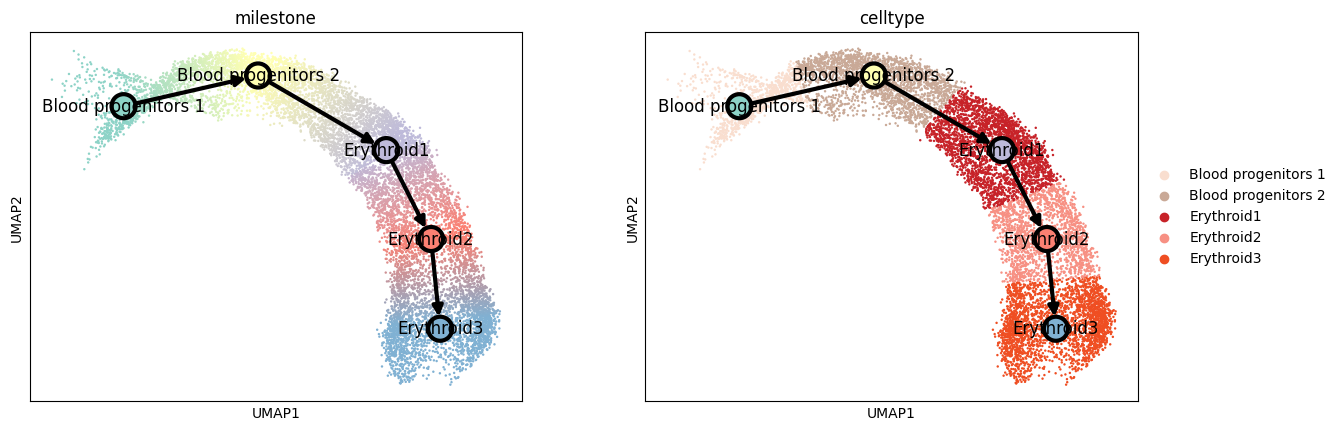

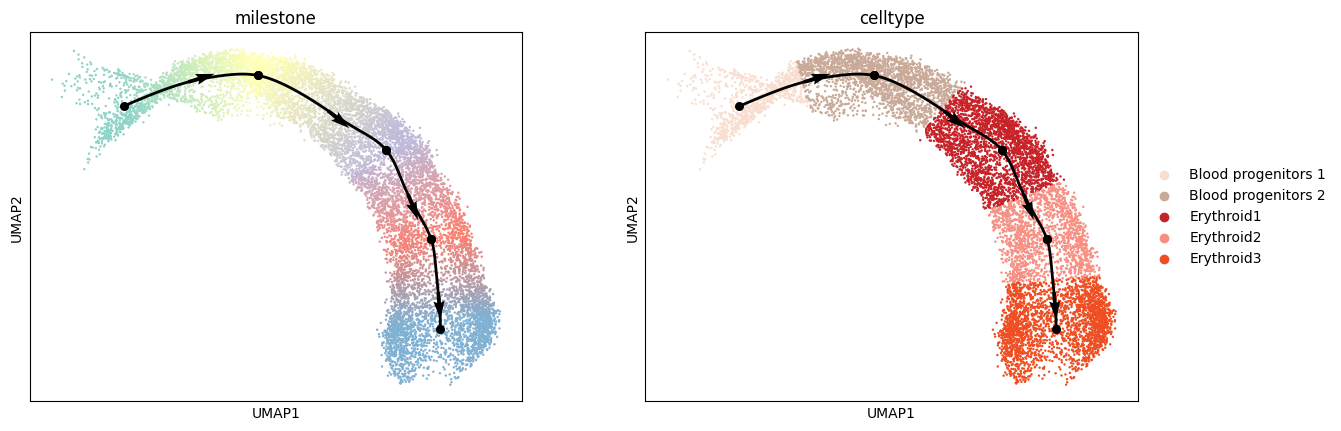

In [4]:
cluster_key = "celltype"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年10月09日 16时35分18秒] INFO     find wrapper type: directed                                                 


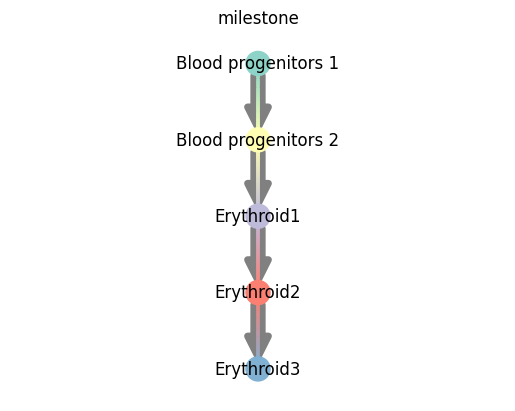

In [5]:
cfe.plot.plot_wrapper(fadata)

[2025年10月09日 16时41分16秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x790de51d7910> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x790e26e6aa10>                                                                   
[2025年10月09日 16时41分21秒] DEBUG    Add trajectory by wrapper type: linear                                      
                        DEBUG    Wrapper type: linear                                                              
                        DEBUG    FateAnnData add_trajectory                                                        
[2025年10月09日 16时41分22秒] DEBUG    plot_trajectory                                    

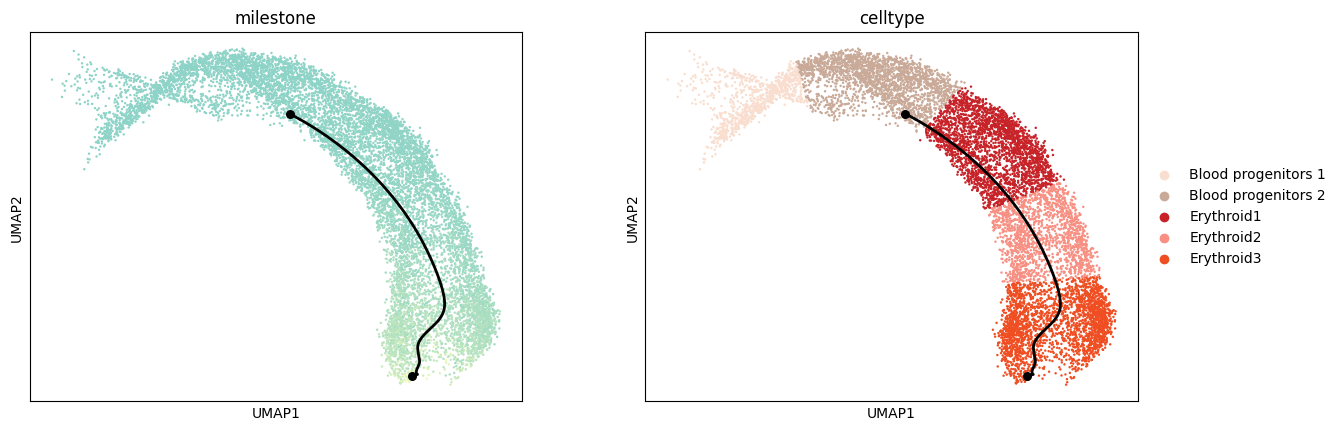

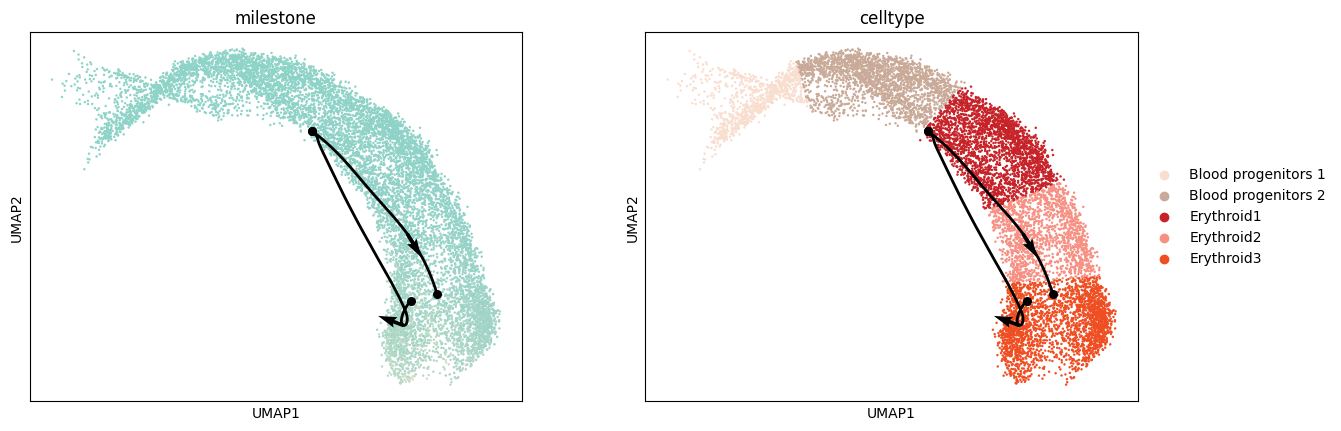

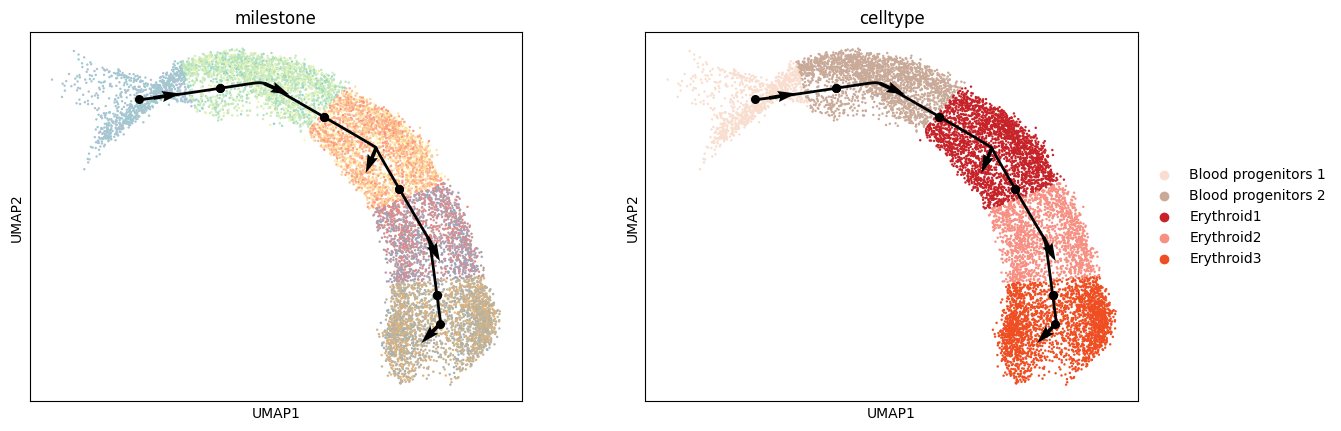

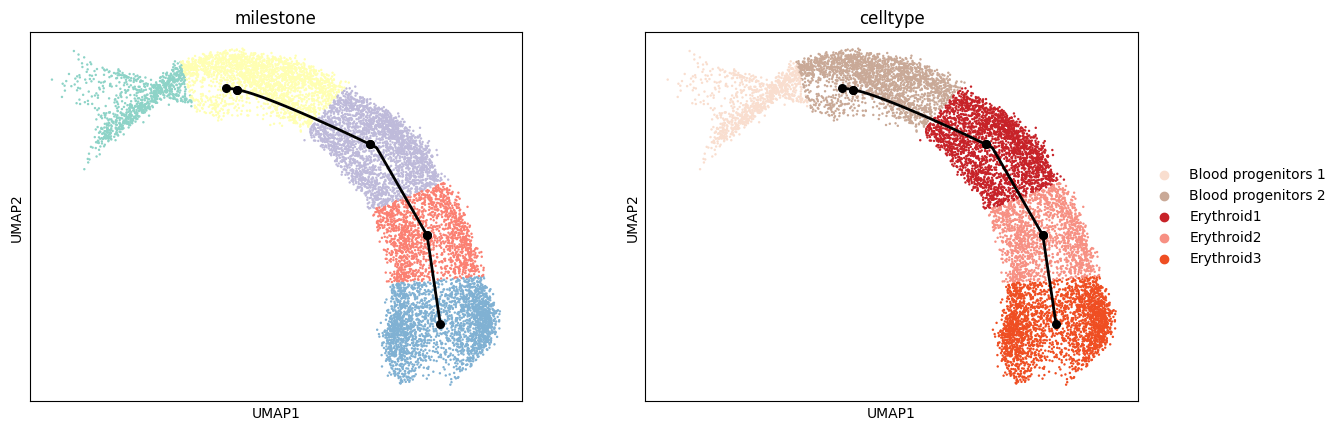

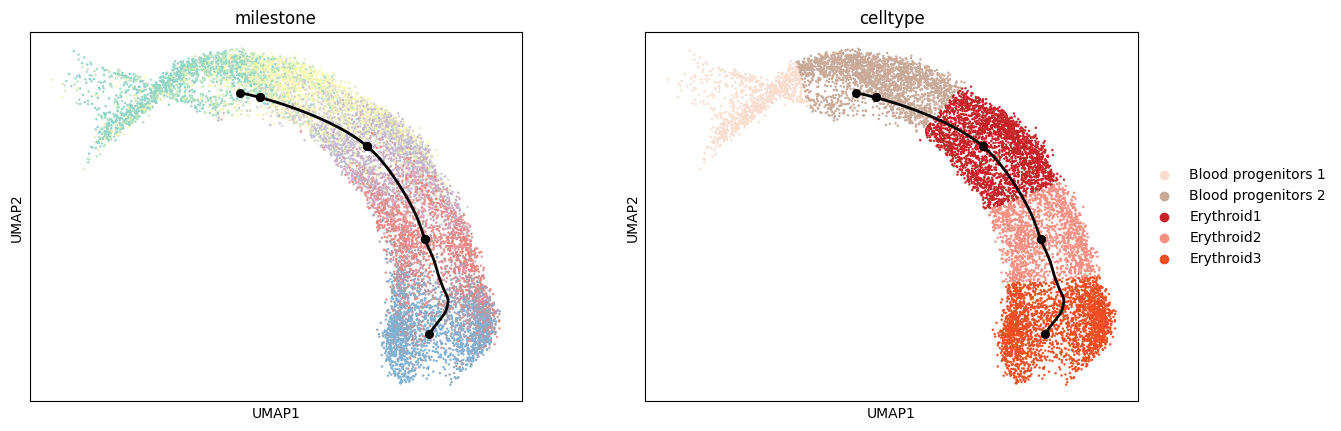

In [6]:
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["comp1", "state_comp","paga","cluster_mst","projection_mst"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [9]:
model_name_list = ["comp1", "state_comp","paga","cluster_mst","projection_mst"]

In [10]:
new_fadata = cfe.data.FateAnnData(
        X=fadata.X,
        obs=fadata.obs,
        uns=fadata.uns
    )
for i in model_name_list: 
    new_fadata.model_name = i
    new_fadata.milestone_wrapper = fadata.trajectory_history_dict[i]['milestone_wrapper']
    new_fadata.add_waypoints()
    # 使用单引号避免冲突
    print(f"{i}'s milestone_network is:\n {new_fadata.milestone_wrapper['milestone_network']}")
    print(f"{i}'s progressions is:\n {new_fadata.milestone_wrapper['progressions']}")

    

prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
new_fadata.add_prior_information(**prior_information)  # add prior information to fadata

KeyError: 'comp1'

In [ ]:
metrics = cfe.metric.metrics
metrics

拓扑部分(调用了简化)

In [ ]:
metric_topology_dict = {}
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    metric_topology_dict[model_name] = model_metric

df1 = pd.DataFrame(metric_topology_dict).T
df1.index=parsed_model_name_list
df1

拓扑部分（未简化）

In [ ]:
metric_topology_dict = {}
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    metric_topology_dict[model_name] = model_metric

df7 = pd.DataFrame(metric_topology_dict).T
df7.index=parsed_model_name_list
df7

查看correlation表现

In [ ]:
metric_correlation_dict = {}
metric_id_list = metrics[metrics["category"] == "cell positions"]["metric_id"].tolist()
for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    metric_correlation_dict[model_name] = model_metric

df2 = pd.DataFrame(metric_correlation_dict).T
df2.index=parsed_model_name_list
df2

查看各个F1 score的表现

In [ ]:
#映射到里程碑上
F1_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    F1_dict[j]=calculate_mapping(new_fadata,grouping='milestones',simplify=True,ref_model= "ref",pred_model= i)

df3 = pd.DataFrame.from_dict(F1_dict, orient='index')
df3

In [ ]:
#映射到分支上
F1_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    F1_dict[j]=calculate_mapping(new_fadata,grouping='branches',simplify=True,ref_model= "ref",pred_model= i)

df4 = pd.DataFrame.from_dict(F1_dict, orient='index')
df4

试试position_predict相关指标的表现

In [ ]:
parsed_model_name_list

In [ ]:
position_predict_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    position_predict_dict[j]=calculate_position_predict(
        new_fadata,
        ref_model='ref',
        pred_model=i,
        metrics=["rf_mse","rf_rsq","rf_nmse","lm_mse","lm_rsq","lm_nmse"]
    )['summary']

position_predict_dict

In [ ]:
df5 = pd.DataFrame.from_dict(position_predict_dict, orient='index')
df5

计算cor和wcor相关的表现(这里利用fadata，因为new_fadata在表达矩阵上可能存在问题)

In [ ]:

sc.pp.normalize_total(fadata)
# Logarithmize the data
sc.pp.log1p(fadata)
# Feature selection
sc.pp.highly_variable_genes(fadata, n_top_genes=3000)
fadata = fadata[:, fadata.var.highly_variable]
fadata

In [ ]:
featureimp_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    featureimp_dict[j]=calculate_featureimp_cor(
            fadata,
            "ref",
            i,
            fadata.X,
            fi_ranger_rf_lite()
    )

df6 = pd.DataFrame.from_dict(featureimp_dict, orient='index')
df6

NameError: name 'metrics' is not defined